# External force estimation with observer and Kalman variants

This notebook compares realtime torque-residual filters before projecting force with `F_hat = J^{-T} tau_ext_filtered`. The new Kalman modes use the LSTM torque residual as the measurement and estimate external joint torque online. The force sensor is used only afterward for validation plots, RMSE, and coverage checks.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from external_force_ci import (
    CHANNELS,
    default_data_root,
    run_pipeline,
    save_results_csv,
    plot_force_ci,
    plot_sigma_model,
    plot_velocity_uncertainty_context,
    plot_ci_width_vs_velocity,
)

## Configuration

In [2]:
data_root = default_data_root()
output_dir = Path("outputs_notebook")

data = "free_space"
rnn = "lstm"
network = "_seal_pred_filtered_torque_si_9_1.csv"

# Your tuned paper-style observer setting.
observer_gain = 15.0  # K_i, 1/s
window_size = 1      # observer and Kalman filters are already online filters

# Bias adaptation hurt in these tests, so keep it off.
bias_gain = 0.0

# Smooth torque-space deadband. For dVRK-Si: joints 1-2 are noisier, joint 3 underestimates,
# so joint 3 gets a smaller deadband multiplier.
deadband_multiplier = 20.0
joint_deadband_multipliers = "1,1,0.25,1,1,1"
smooth_width_multiplier = 0.8

# Kalman torque-residual filter parameters.
kalman_process_scale = 0.08       # larger = faster tracking, smaller = smoother/more lag
kalman_measurement_scale = 1.0    # larger = trust residual measurement less

# Leak-free uncertainty parameters. No force-sensor values are used here.
confidence = 0.95
low_force_gain = 3.0                 # wider band near low estimated contact force
force_scale = 10.0                   # N, decay scale for low-force uncertainty
observer_disagreement_gain = 0.8     # direct torque projection vs filtered estimate disagreement
relative_force_uncertainty = 0.10    # relative model/calibration uncertainty at large force
fz_uncertainty_gain = 2.0            # dVRK-Si z/third-axis uncertainty correction
max_ci_half_width = 12.0             # N, plot/readability cap on half-width

data_root


WindowsPath('D:/_RESEARCH/paper_plot_scripts/dvrk_si_col_9_1')

## Run observer variants

In [4]:
common_kwargs = dict(
    data_root=data_root,
    data=data,
    rnn=rnn,
    network=network,
    observer_gain=observer_gain,
    bias_gain=bias_gain,
    deadband_multiplier=deadband_multiplier,
    joint_deadband_multipliers=joint_deadband_multipliers,
    smooth_width_multiplier=smooth_width_multiplier,
    kalman_process_scale=kalman_process_scale,
    kalman_measurement_scale=kalman_measurement_scale,
    confidence=confidence,
    low_force_gain=low_force_gain,
    force_scale=force_scale,
    observer_disagreement_gain=observer_disagreement_gain,
    relative_force_uncertainty=relative_force_uncertainty,
    fz_uncertainty_gain=fz_uncertainty_gain,
    max_ci_half_width=max_ci_half_width,
)

results_by_mode = {
    "observer_K15": run_pipeline(estimator_mode="observer", window_size=window_size, **common_kwargs),
    "bias_gate_K15_db20": run_pipeline(estimator_mode="bias_gate", window_size=window_size, **common_kwargs),
    "two_time_scale_K15_db20": run_pipeline(estimator_mode="two_time_scale", window_size=window_size, **common_kwargs),
    "kalman_raw_q008": run_pipeline(estimator_mode="kalman", window_size=window_size, **common_kwargs),
    "kalman_smooth_db20_q008": run_pipeline(estimator_mode="kalman_smooth_deadband", window_size=window_size, **common_kwargs),
    "torque_smooth_db20": run_pipeline(estimator_mode="torque_smooth_deadband", window_size=window_size, **common_kwargs),
    "direct_window30": run_pipeline(estimator_mode="direct", window_size=1, **common_kwargs),
}

summary = pd.DataFrame(
    {name: result.rmse[:3] for name, result in results_by_mode.items()},
    index=["Fx", "Fy", "Fz"],
).T
summary["mean"] = summary.mean(axis=1)
summary.sort_values("mean")


,Fx,Fy,Fz,mean
kalman_smooth_db20_q008,1.679981,1.626643,1.425742,1.577455
torque_smooth_db20,1.670029,1.626021,1.438499,1.578183
two_time_scale_K15_db20,2.416082,1.525376,1.362496,1.767985
bias_gate_K15_db20,2.442248,1.502051,1.374661,1.772987
observer_K15,2.433301,2.372639,1.470326,2.092088
kalman_raw_q008,2.452772,2.383172,1.457764,2.097903
direct_window30,3.273335,3.019395,1.556828,2.616519


## Pick the active result for plots and CSV

In [22]:
# Current recommended experimental mode from the sweep.
active_name = "kalman_smooth_db20_q008"
results = results_by_mode[active_name]
print(f"Active result: {active_name}")

Active result: kalman_smooth_db20_q008


## Save outputs

In [ ]:
csv_path = save_results_csv(results, output_dir)
force_plot = plot_force_ci(results, output_dir)
sigma_plot = plot_sigma_model(results, output_dir)
velocity_context_plot = plot_velocity_uncertainty_context(results, output_dir)
velocity_width_plot = plot_ci_width_vs_velocity(results, output_dir)

print(csv_path)
print(force_plot)
print(sigma_plot)
print(velocity_context_plot)
print(velocity_width_plot)


## Inspect confidence bands without using ground truth

In [23]:
estimated_mag = np.linalg.norm(results.force[:, :3], axis=1)
near_zero_idx = estimated_mag.argmin()
large_force_idx = estimated_mag.argmax()

print(f"Smallest estimated force magnitude: {estimated_mag[near_zero_idx]:.6f} N")
print(f"Largest estimated force magnitude:  {estimated_mag[large_force_idx]:.6f} N")
print("Approx. full 95% band width, small estimate vs large estimate:")
for idx, channel in enumerate(CHANNELS[:3]):
    near_zero_width = 2.0 * results.ci_half_width[near_zero_idx, idx]
    large_width = 2.0 * results.ci_half_width[large_force_idx, idx]
    print(f"{channel}: {near_zero_width:.3f} N vs {large_width:.3f} N")

Smallest estimated force magnitude: 0.020868 N
Largest estimated force magnitude:  50.163009 N
Approx. full 95% band width, small estimate vs large estimate:
Fx: 6.724 N vs 11.753 N
Fy: 8.285 N vs 15.331 N
Fz: 3.493 N vs 18.679 N


## Force plots with shaded 95% bands

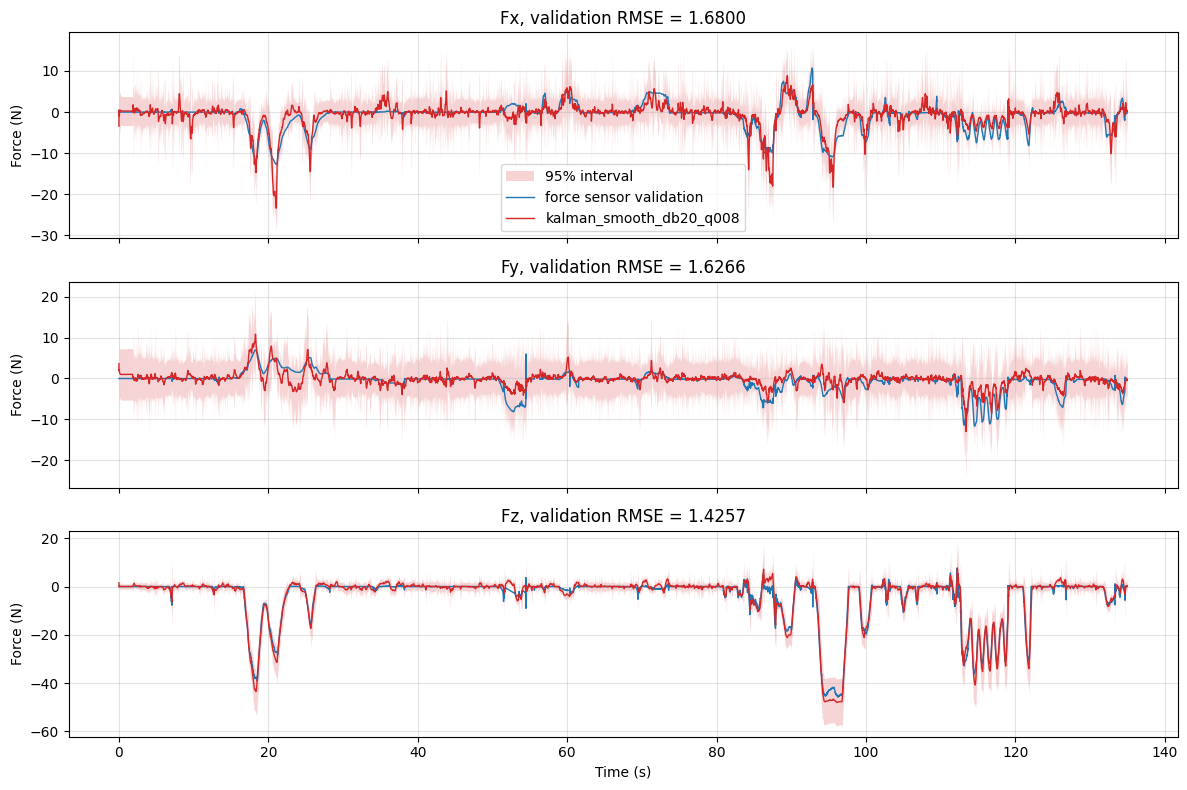

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, channel in zip(axes, range(3)):
    ax.fill_between(results.time, results.ci_lower[:, channel], results.ci_upper[:, channel], color="tab:red", alpha=0.20, linewidth=0, label="95% interval")
    ax.plot(results.time, results.real_force[:, channel], color="tab:blue", linewidth=1.0, label="force sensor validation")
    ax.plot(results.time, results.force[:, channel], color="tab:red", linewidth=1.0, label=active_name)
    ax.set_title(f"{CHANNELS[channel]}, validation RMSE = {results.rmse[channel]:.4f}")
    ax.set_ylabel("Force (N)")
    ax.grid(True, alpha=0.35)
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="best")
fig.tight_layout()

## CI width model

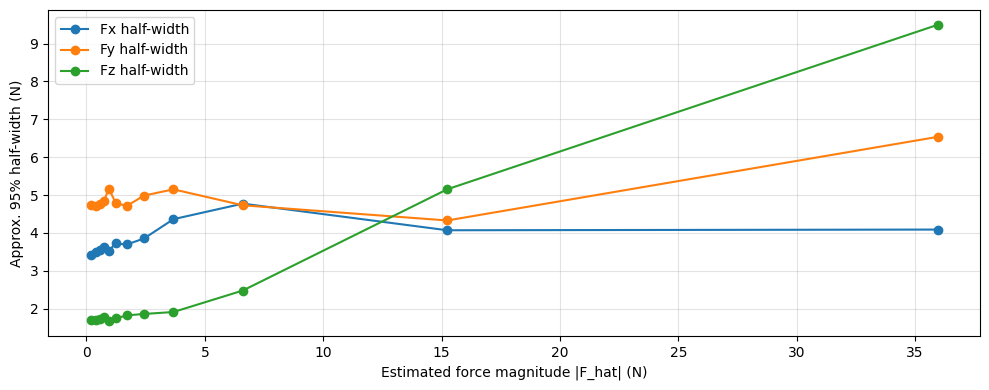

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
for channel in range(3):
    ax.plot(results.sigma_bin_centers, 1.959963984540054 * results.sigma_by_channel[:, channel], marker="o", label=f"{CHANNELS[channel]} half-width")
ax.set_xlabel("Estimated force magnitude |F_hat| (N)")
ax.set_ylabel("Approx. 95% half-width (N)")
ax.grid(True, alpha=0.35)
ax.legend(loc="best")
fig.tight_layout()

## Velocity context for force uncertainty

These plots are not velocity confidence intervals. They show tool speed from `J qdot` alongside the force CI width, so we can check whether force uncertainty is mainly driven by fast motion or by the force-estimation model itself.


outputs_notebook\velocity_with_force_uncertainty.png


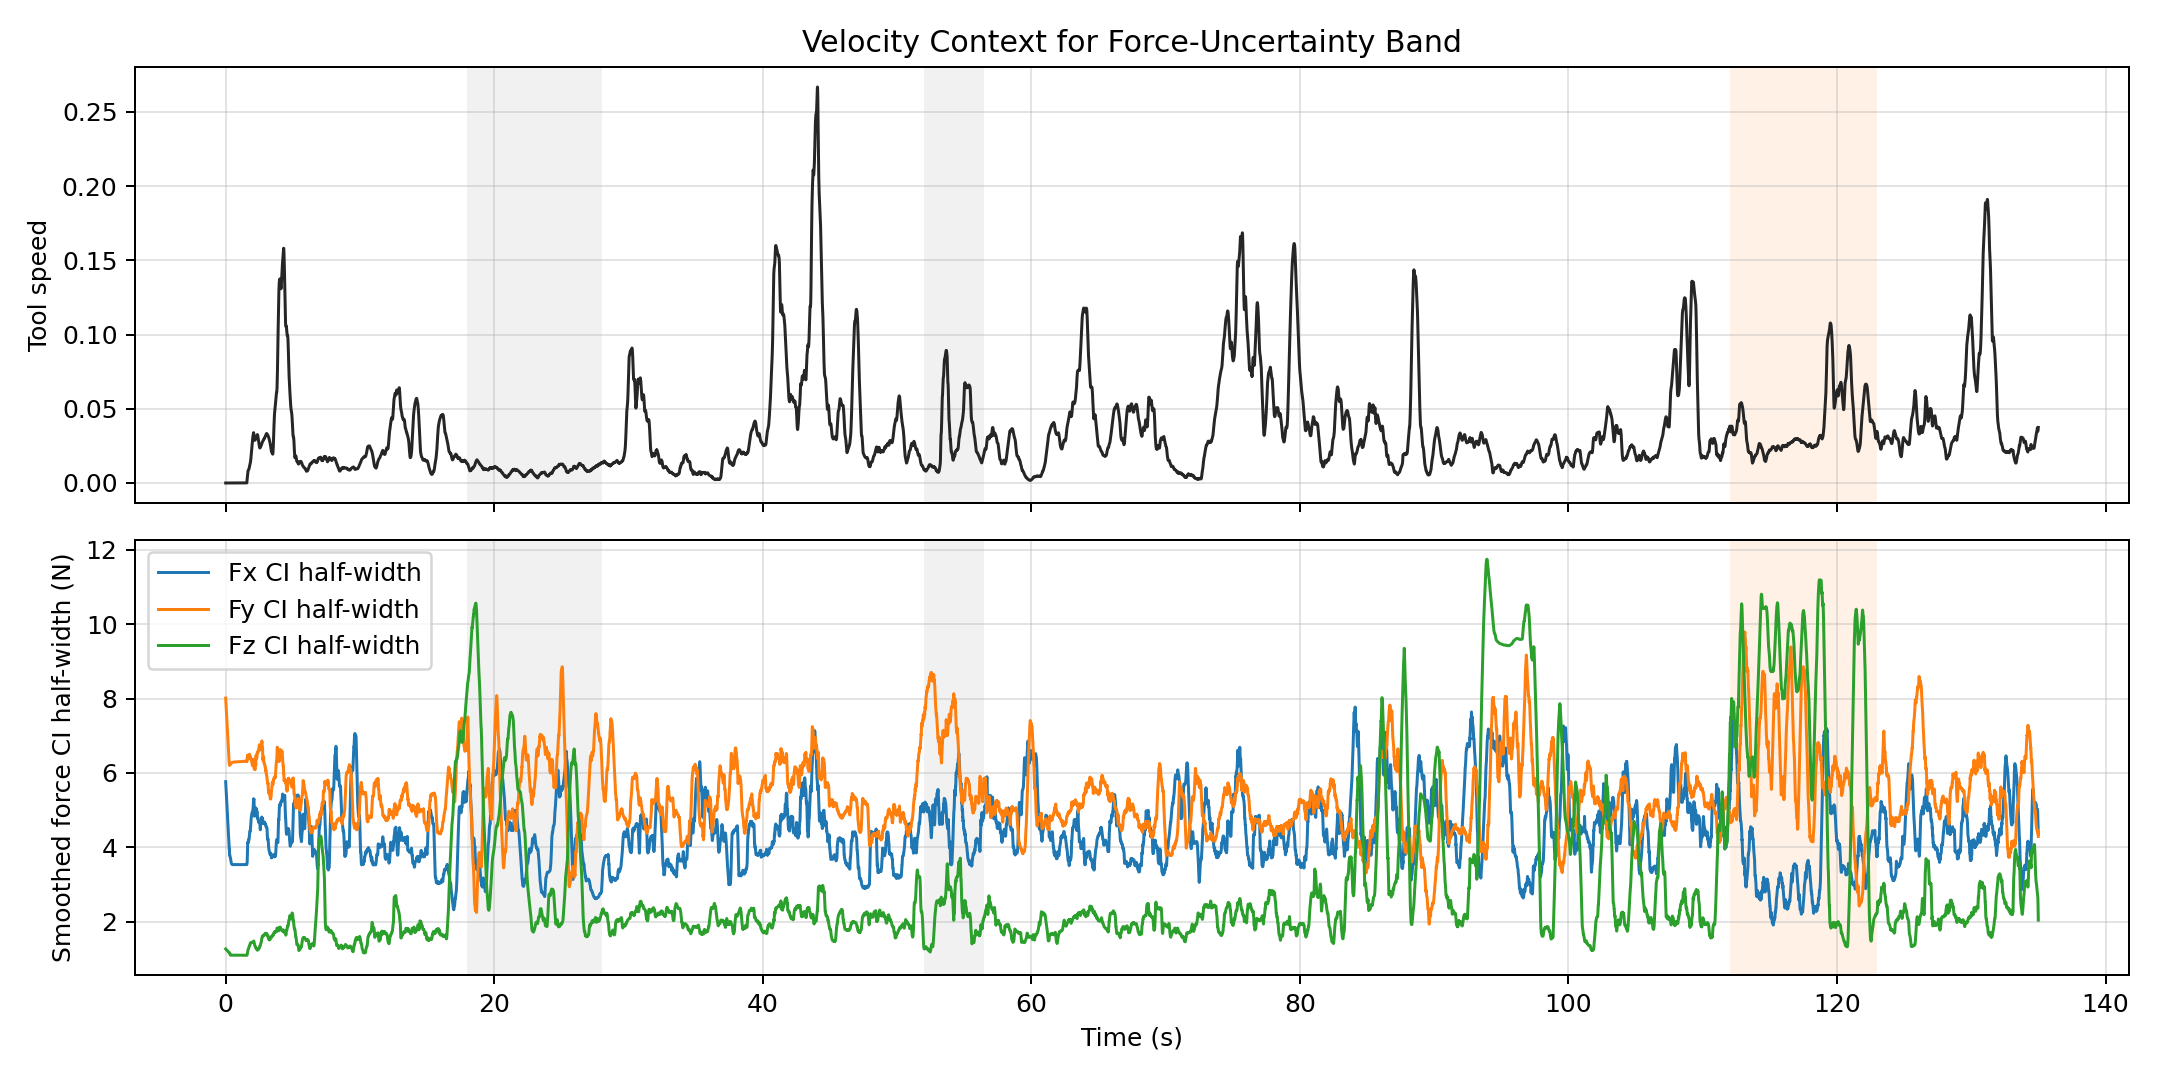

outputs_notebook\ci_width_vs_velocity.png


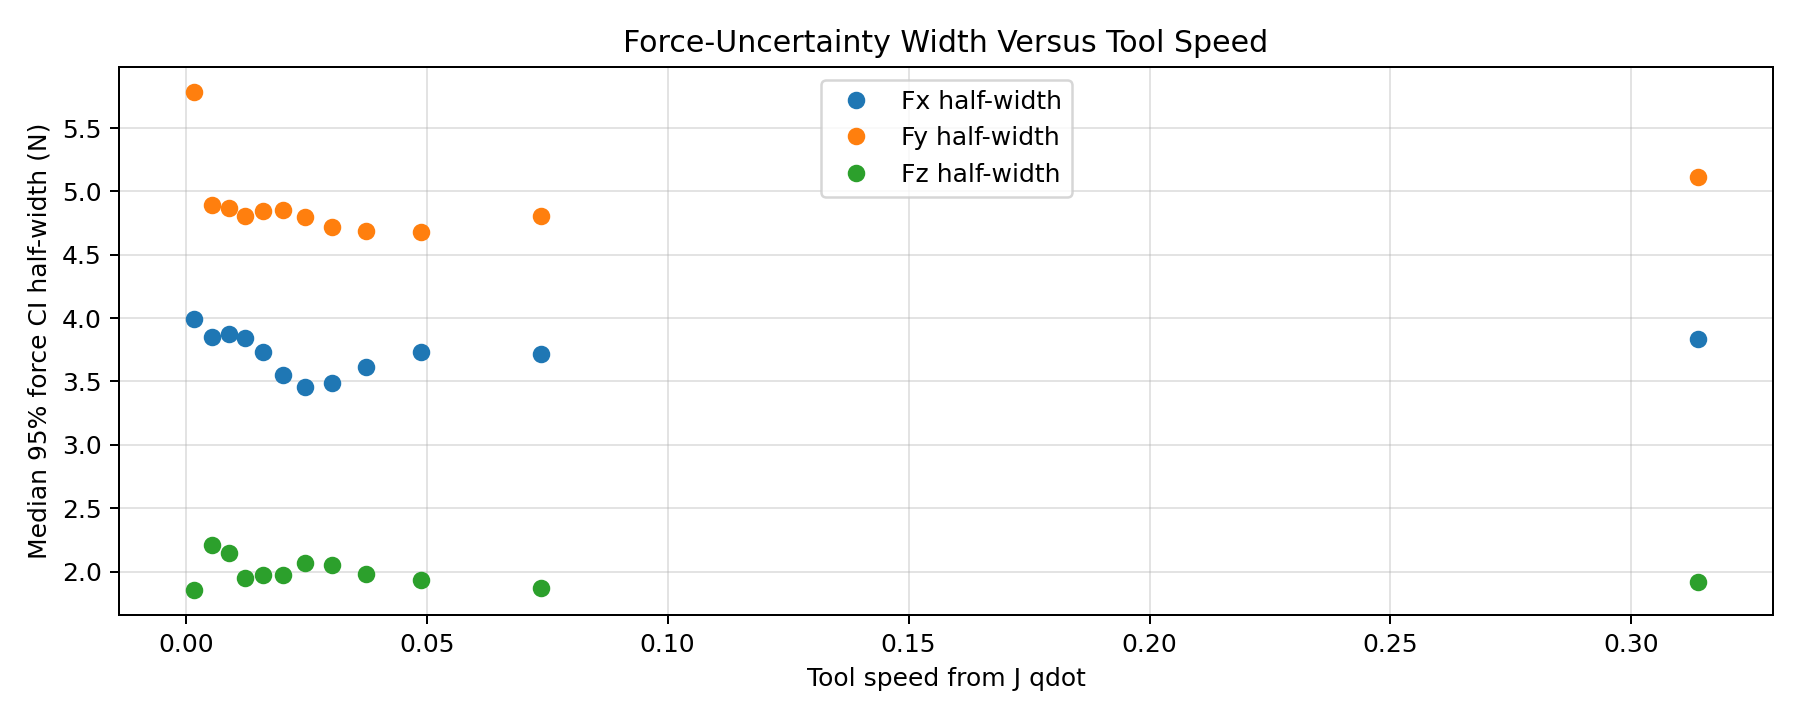

In [26]:
from IPython.display import Image, display

velocity_context_plot = plot_velocity_uncertainty_context(results, output_dir)
velocity_width_plot = plot_ci_width_vs_velocity(results, output_dir)

print(velocity_context_plot)
display(Image(filename=str(velocity_context_plot)))

print(velocity_width_plot)
display(Image(filename=str(velocity_width_plot)))
